In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from itertools import product 

df = pd.read_csv("df_hmm_var.csv", parse_dates=["date"])
df = df.dropna(subset=['hmm_regime', 'hmm_prob_high']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nRegime distribution:")
print(df['hmm_regime'].value_counts().sort_index())

Dataset shape: (3489, 49)
Date range: 2016-07-14 00:00:00 to 2026-01-31 00:00:00

Regime distribution:
hmm_regime
0.0    1975
1.0    1149
Name: count, dtype: int64


In [2]:
# Use ALL available features (matching baseline SVR-L)
exclude_cols = [
    'date', 
    'target_vol', 
    'target_var', 
    'realized_volatility', 
    'realized_variance',
    'rvol_1',
    'rvol_2',
    'rvol_3',
    'rvol_7',
    'rvol_30',
    'hmm_regime',           
    'hmm_regime_lag1',
    "hmm_prob_high_lag1",
    "hmm_prob_high_lag2",
    "hmm_prob_high_roll5"       
]

# Get all features
all_cols = df.columns.tolist()
svr_features = [col for col in all_cols if col not in exclude_cols]

print(f"\nTotal SVR features: {len(svr_features)}")
print(f"Features: {svr_features}")

# Check for missing values
print(f"\nMissing values in SVR features:")
missing_counts = df[svr_features + ['target_var']].isnull().sum()
print(missing_counts[missing_counts > 0])

# Remove rows with NaN
df_clean = df.dropna(subset=svr_features + ['target_var']).reset_index(drop=True)

print(f"\nAfter removing NaN: {df_clean.shape}")
print(df_clean[svr_features].describe())


Total SVR features: 34
Features: ['log_return', 'gtrend_pct_change', 'blockchain_diff_log_n_transactions', 'blockchain_diff_log_transaction_fee_usd', 'blockchain_diff_log_n_unique_addresses', 'blockchain_diff_log_transaction_volume_usd', 'log_volume', 'gold_close_ret', 'silver_close_ret', 'brent_close_ret', 'dji_close_ret', 'spx_close_ret', 'rut_close_ret', 'nasdaq_close_ret', 'usdcny_close_ret', 'usdeur_close_ret', 'gold_volume_chg', 'silver_volume_chg', 'brent_volume_chg', 'dji_volume_chg', 'spx_volume_chg', 'rut_volume_chg', 'nasdaq_volume_chg', 'vix_close_chg', 'hash-rate_chg', 'difficulty_chg', 'median-confirmation-time_chg', 'blockchain_log_mempool_count_chg', 'rvar_1', 'rvar_2', 'rvar_3', 'rvar_7', 'rvar_30', 'hmm_prob_high']

Missing values in SVR features:
hmm_prob_high    365
target_var         1
dtype: int64

After removing NaN: (3124, 49)
        log_return  gtrend_pct_change  blockchain_diff_log_n_transactions  \
count  3124.000000        3124.000000                      

PRINCIPAL COMPONENT ANALYSIS

Feature breakdown:
  Total features: 34
  HMM features (excluded from PCA): 1
  Non-HMM features (for PCA): 33

Explained variance by component:
  PC1: 0.1426 (cumulative: 0.1426)
  PC2: 0.1250 (cumulative: 0.2676)
  PC3: 0.1022 (cumulative: 0.3698)
  PC4: 0.0979 (cumulative: 0.4676)
  PC5: 0.0600 (cumulative: 0.5276)
  PC6: 0.0526 (cumulative: 0.5802)
  PC7: 0.0430 (cumulative: 0.6232)
  PC8: 0.0386 (cumulative: 0.6618)
  PC9: 0.0311 (cumulative: 0.6929)
  PC10: 0.0301 (cumulative: 0.7231)

Components needed for 95% variance: 23
Components needed for 90% variance: 18


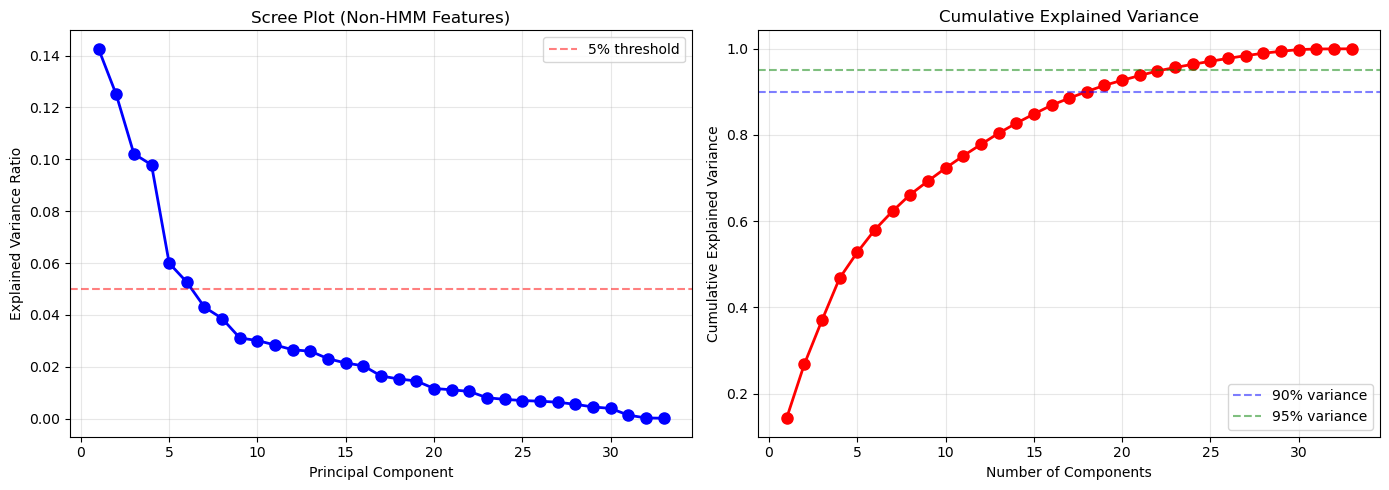


SELECTED: 18 PCA components (explains 90.1% of variance)
PLUS: 1 HMM feature(s) kept separately
TOTAL FEATURES: 19

Final feature set:
  PCA components: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18']
  HMM features: ['hmm_prob_high']

PCA-transformed dataset shape: (3124, 21)
Dimensionality reduction: 33 → 18 (45.5% reduction)

Top 5 feature loadings per component:

  PC1 (explains 14.3% variance):
    spx_close_ret                           : -0.413
    nasdaq_close_ret                        : -0.396
    dji_close_ret                           : -0.395
    rut_close_ret                           : -0.385
    vix_close_chg                           : +0.354

  PC2 (explains 12.5% variance):
    rvar_2                                  : +0.420
    rvar_3                                  : +0.413
    rvar_1                                  : +0.393
    rvar_7                                  : +0.3

In [3]:
# Principal Component Analysis (PCA) - EXCLUDING HMM Features

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("="*70)
print("PRINCIPAL COMPONENT ANALYSIS")
print("="*70)

# CRITICAL: Separate HMM features from other features
hmm_features = ['hmm_prob_high']
non_hmm_features = [f for f in svr_features if f not in hmm_features]

print(f"\nFeature breakdown:")
print(f"  Total features: {len(svr_features)}")
print(f"  HMM features (excluded from PCA): {len(hmm_features)}")
print(f"  Non-HMM features (for PCA): {len(non_hmm_features)}")

# Apply PCA only to non-HMM features
X_non_hmm = df_clean[non_hmm_features].values
X_hmm = df_clean[hmm_features].values
y = df_clean['target_var'].values

# Standardize non-HMM features (required for PCA)
scaler_pca = StandardScaler()
X_non_hmm_scaled = scaler_pca.fit_transform(X_non_hmm)

# Fit PCA to determine optimal number of components
pca_full = PCA()
pca_full.fit(X_non_hmm_scaled)

# Explained variance analysis
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"\nExplained variance by component:")
for i in range(min(10, len(explained_variance_ratio))):
    print(f"  PC{i+1}: {explained_variance_ratio[i]:.4f} (cumulative: {cumulative_variance_ratio[i]:.4f})")

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")

# Find number of components for 90% variance
n_components_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(explained_variance_ratio) + 1), 
             explained_variance_ratio, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (Non-HMM Features)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.05, color='r', linestyle='--', alpha=0.5, label='5% threshold')
axes[0].legend()

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1), 
             cumulative_variance_ratio, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.90, color='b', linestyle='--', alpha=0.5, label='90% variance')
axes[1].axhline(y=0.95, color='g', linestyle='--', alpha=0.5, label='95% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Select optimal number of components (using 90% as threshold)
n_components = n_components_90
print(f"\n" + "="*70)
print(f"SELECTED: {n_components} PCA components (explains {cumulative_variance_ratio[n_components-1]:.1%} of variance)")
print(f"PLUS: {len(hmm_features)} HMM feature(s) kept separately")
print(f"TOTAL FEATURES: {n_components + len(hmm_features)}")
print("="*70)

# Apply PCA transformation
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_non_hmm_scaled)

# Create new feature names
pca_feature_names = [f'PC{i+1}' for i in range(n_components)]

# CRITICAL: Combine PCA components with HMM features
X_combined = np.hstack([X_pca, X_hmm])
combined_feature_names = pca_feature_names + hmm_features

# Create df_pca for subsequent analysis
df_pca = pd.DataFrame(X_combined, columns=combined_feature_names, index=df_clean.index)
df_pca['target_var'] = y
df_pca['date'] = df_clean['date'].values

print(f"\nFinal feature set:")
print(f"  PCA components: {pca_feature_names}")
print(f"  HMM features: {hmm_features}")
print(f"\nPCA-transformed dataset shape: {df_pca.shape}")
print(f"Dimensionality reduction: {len(non_hmm_features)} → {n_components} ({(1 - n_components/len(non_hmm_features))*100:.1f}% reduction)")

# Show component loadings (top 5 features per component)
print(f"\nTop 5 feature loadings per component:")
for i in range(min(3, n_components)):
    print(f"\n  PC{i+1} (explains {explained_variance_ratio[i]:.1%} variance):")
    loadings = pd.DataFrame({
        'feature': non_hmm_features,
        'loading': np.abs(pca.components_[i])
    }).sort_values('loading', ascending=False)
    for j in range(5):
        print(f"    {loadings.iloc[j]['feature']:40s}: {pca.components_[i][loadings.index[j]]:+.3f}")

# Save PCA object and scaler for later use
import pickle
with open('pca_model.pkl', 'wb') as f:
    pickle.dump({
        'pca': pca, 
        'scaler': scaler_pca, 
        'non_hmm_features': non_hmm_features,
        'hmm_features': hmm_features,
        'n_components': n_components
    }, f)

print("\nPCA model saved to: pca_model.pkl")
print("\n" + "="*70)
print("HMM FEATURE PRESERVED ✓")
print("hmm_prob_high remains as a separate feature with full signal strength")
print("="*70)

In [4]:
df_clean = df_pca.copy()
svr_features = pca_feature_names  # Update feature list to PCA components

# 60/25/15 Train/Val/Test
total_len = len(df_clean)
train_size = int(total_len * 0.60)
val_size = int(total_len * 0.25)

train_end = train_size
val_start = train_size
val_end = train_size + val_size
test_start = val_end

print(f"Train: {0:4d} to {train_end:4d} ({train_size:4d} days) | {df_clean['date'].iloc[0]} to {df_clean['date'].iloc[train_end-1]}")
print(f"Val:   {val_start:4d} to {val_end:4d} ({val_size:4d} days) | {df_clean['date'].iloc[val_start]} to {df_clean['date'].iloc[val_end-1]}")
print(f"Test:  {test_start:4d} to {total_len:4d} ({total_len - test_start:4d} days) | {df_clean['date'].iloc[test_start]} to {df_clean['date'].iloc[-1]}")

window_size = 365
print(f"\nModel: SVR with linear kernel on {len(svr_features)} principal components")
print(f"Rolling window: {window_size} days")

Train:    0 to 1874 (1874 days) | 2017-07-13 00:00:00 to 2022-08-29 00:00:00
Val:   1874 to 2655 ( 781 days) | 2022-08-30 00:00:00 to 2024-10-18 00:00:00
Test:  2655 to 3124 ( 469 days) | 2024-10-19 00:00:00 to 2026-01-30 00:00:00

Model: SVR with linear kernel on 18 principal components
Rolling window: 365 days


In [5]:
# Hyperparameter Tuning

with open('pca_model.pkl', 'rb') as f:
    pca_setup = pickle.load(f)
    n_components = pca_setup['n_components']
    non_hmm_features = pca_setup['non_hmm_features']
    hmm_features = pca_setup['hmm_features']

C_values = [0.1, 1.0, 10.0]
epsilon_values = [0.001, 0.01, 0.1]

val_sample_indices = range(val_start, val_end, 5)
grid_results = []
total_configs = len(C_values) * len(epsilon_values)

print(f"Testing {total_configs} configurations on {len([i for i in val_sample_indices if i >= window_size])} samples...")

config_num = 0
for C, epsilon in product(C_values, epsilon_values):
    config_num += 1
    if config_num % 3 == 0:
        print(f"Progress: {config_num}/{total_configs}")
    
    preds = []
    actuals = []
    
    for i in val_sample_indices:
        if i < window_size:
            continue
        
        # Get original features for this window
        train_X_non_hmm = df.iloc[i - window_size : i][non_hmm_features].values
        train_X_hmm = df.iloc[i - window_size : i][hmm_features].values
        train_y = df.iloc[i - window_size : i]['target_var'].values
        
        test_X_non_hmm = df.iloc[i:i+1][non_hmm_features].values
        test_X_hmm = df.iloc[i:i+1][hmm_features].values
        target_val = df.iloc[i]['target_var']
        
        try:
            # PCA transformation on non-HMM features only
            scaler_X = StandardScaler()
            train_X_non_hmm_scaled = scaler_X.fit_transform(train_X_non_hmm)
            test_X_non_hmm_scaled = scaler_X.transform(test_X_non_hmm)
            
            # Fit PCA on training window
            pca_window = PCA(n_components=n_components)
            train_X_pca = pca_window.fit_transform(train_X_non_hmm_scaled)
            test_X_pca = pca_window.transform(test_X_non_hmm_scaled)
            
            # CRITICAL: Combine PCA components with HMM features
            train_X_combined = np.hstack([train_X_pca, train_X_hmm])
            test_X_combined = np.hstack([test_X_pca, test_X_hmm])
            
            # Scale target
            scaler_y = StandardScaler()
            train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
            
            # Fit SVR on combined features
            model = SVR(kernel='linear', C=C, epsilon=epsilon)
            model.fit(train_X_combined, train_y_scaled)
            
            # Predict and inverse transform
            pred_scaled = model.predict(test_X_combined)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            pred = np.clip(pred, 0, 0.15)
            
            preds.append(pred)
            actuals.append(target_val)
            
        except:
            fallback = preds[-1] if preds else 0.02
            preds.append(fallback)
            actuals.append(target_val)
    
    if len(preds) > 0:
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        grid_results.append({'C': C, 'epsilon': epsilon, 'RMSE': rmse})


results_df = pd.DataFrame(grid_results).sort_values('RMSE')

print("\n" + "="*60)
print("TOP 10 CONFIGURATIONS")
print("="*60)
print(results_df.head(10).to_string(index=False))

best_config = results_df.iloc[0]
best_C = best_config['C']
best_epsilon = best_config['epsilon']

print(f"\n" + "="*60)
print("BEST CONFIGURATION")
print("="*60)
print(f"C:       {best_C}")
print(f"epsilon: {best_epsilon}")
print(f"Validation RMSE: {best_config['RMSE']:.6f}")
print("="*60)

Testing 9 configurations on 157 samples...
Progress: 3/9
Progress: 6/9
Progress: 9/9

TOP 10 CONFIGURATIONS
   C  epsilon     RMSE
10.0    0.100 0.001117
 1.0    0.100 0.001118
 0.1    0.100 0.001120
 1.0    0.010 0.001122
10.0    0.010 0.001122
 1.0    0.001 0.001124
 0.1    0.010 0.001124
10.0    0.001 0.001125
 0.1    0.001 0.001127

BEST CONFIGURATION
C:       10.0
epsilon: 0.1
Validation RMSE: 0.001117


In [6]:
best_C = 1
best_epsilon = 0.001

In [7]:
val_preds = []
val_actuals = []
val_dates = []
failures = 0

print(f"\nRunning full validation with C={best_C}, epsilon={best_epsilon}...")

for i in range(val_start, val_end):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 0, 0.15)
        
        val_preds.append(pred)
        val_actuals.append(target_val)
        val_dates.append(current_date)
        
    except:
        failures += 1
        fallback = val_preds[-1] if val_preds else 0.02
        val_preds.append(fallback)
        val_actuals.append(target_val)
        val_dates.append(current_date)


Running full validation with C=1, epsilon=0.001...


In [8]:
val_preds = np.array(val_preds)
val_actuals = np.array(val_actuals)

val_rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
val_mae = mean_absolute_error(val_actuals, val_preds)
val_qlike = np.mean(val_actuals / (val_preds + 1e-10) - np.log(val_actuals / (val_preds + 1e-10)) - 1)


print(f"\n--- VALIDATION RESULTS ---")
print(f"RMSE:  {val_rmse:.6f}")
print(f"MAE:   {val_mae:.6f}")
print(f"QLIKE:   {val_qlike:.6f}")
print(f"Failures: {failures}")
print(f"Samples: {len(val_preds)}")


--- VALIDATION RESULTS ---
RMSE:  0.000872
MAE:   0.000434
QLIKE:   41395.039355
Failures: 0
Samples: 781


In [9]:
test_preds = []
test_actuals = []
test_dates = []
failures_test = 0

print(f"\nRunning test set evaluation...")

for i in range(test_start, total_len):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 0, 0.15)
        
        test_preds.append(pred)
        test_actuals.append(target_val)
        test_dates.append(current_date)
        
    except:
        failures_test += 1
        fallback = test_preds[-1] if test_preds else 0.02
        test_preds.append(fallback)
        test_actuals.append(target_val)
        test_dates.append(current_date)


Running test set evaluation...


In [10]:
test_preds = np.array(test_preds)
test_actuals = np.array(test_actuals)

test_rmse = np.sqrt(mean_squared_error(test_actuals, test_preds))
test_mae = mean_absolute_error(test_actuals, test_preds)
test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

print(f"\n--- TEST RESULTS ---")
print(f"RMSE:  {test_rmse:.6f}")
print(f"MAE:   {test_mae:.6f}")
print(f"QLIKE:   {test_qlike:.6f}")
print(f"Failures: {failures_test}")
print(f"Samples: {len(test_preds)}")


--- TEST RESULTS ---
RMSE:  0.000645
MAE:   0.000361
QLIKE:   21289.108867
Failures: 0
Samples: 469


In [11]:
summary = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'RMSE': [val_rmse, test_rmse],
    'MAE': [val_mae, test_mae],
    'QLIKE': [val_qlike,test_qlike],
    'Samples': [len(val_preds), len(test_preds)]
})

print("\n" + "="*60)
print("HMM-SVR-L Summary")
print("="*60)
print(summary.to_string(index=False))
print("="*60)
print(f"\nBest Parameters Used:")
print(f"  C: {best_C}")
print(f"  epsilon: {best_epsilon}")
print(f"  Features: {len(svr_features)}")
print("="*60)



HMM-SVR-L Summary
   Dataset     RMSE      MAE        QLIKE  Samples
Validation 0.000872 0.000434 41395.039355      781
      Test 0.000645 0.000361 21289.108867      469

Best Parameters Used:
  C: 1
  epsilon: 0.001
  Features: 18


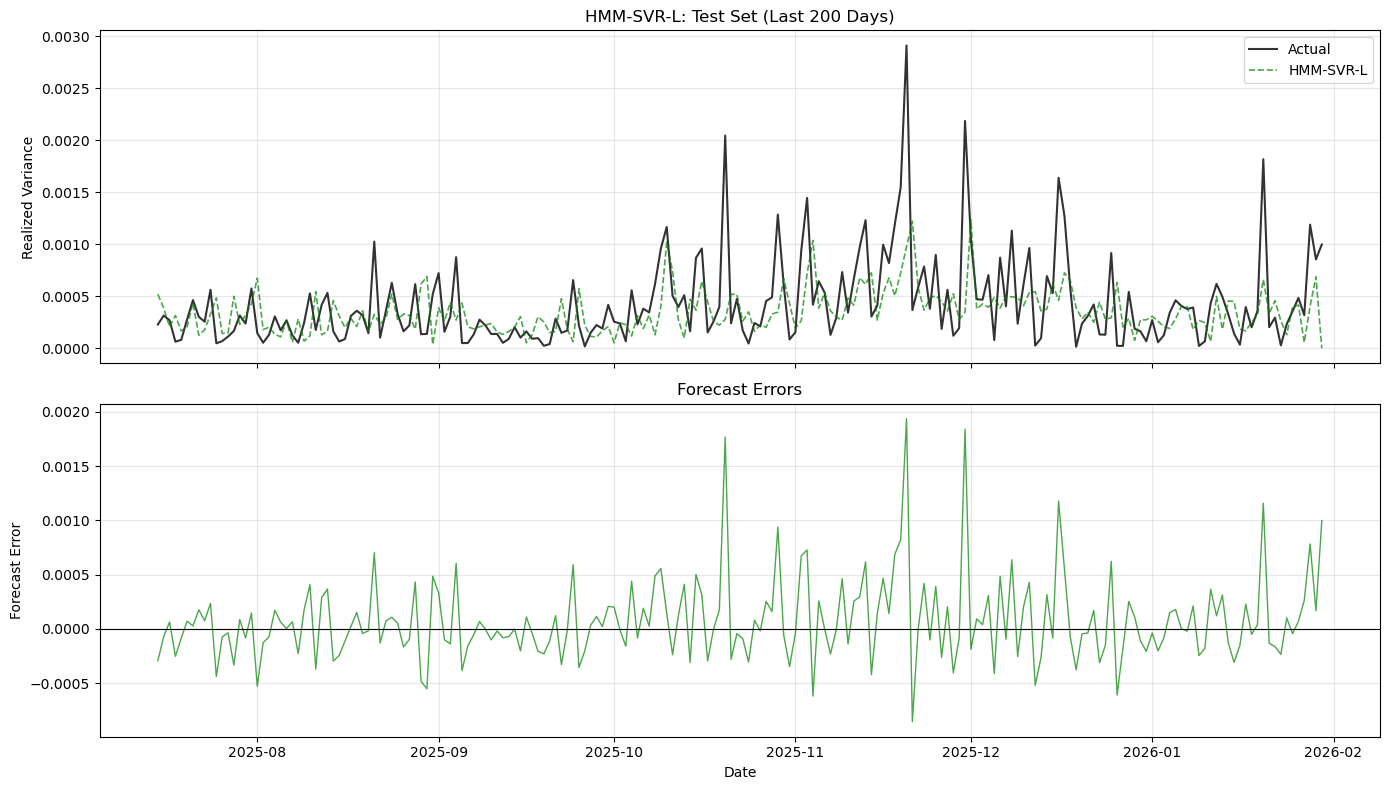

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

plot_n = min(200, len(test_actuals))
plot_dates = test_dates[-plot_n:]
plot_actuals = test_actuals[-plot_n:]
plot_forecasts = test_preds[-plot_n:]

# Panel 1: Actual vs Forecast
axes[0].plot(plot_dates, plot_actuals, label='Actual', color='black', linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label='HMM-SVR-L', color='green', linewidth=1.2, alpha=0.7, linestyle='--')
axes[0].set_ylabel('Realized Variance')
axes[0].set_title(f'HMM-SVR-L: Test Set (Last {plot_n} Days)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Forecast Errors
errors = plot_actuals - plot_forecasts
axes[1].plot(plot_dates, errors, color='green', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].set_title('Forecast Errors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

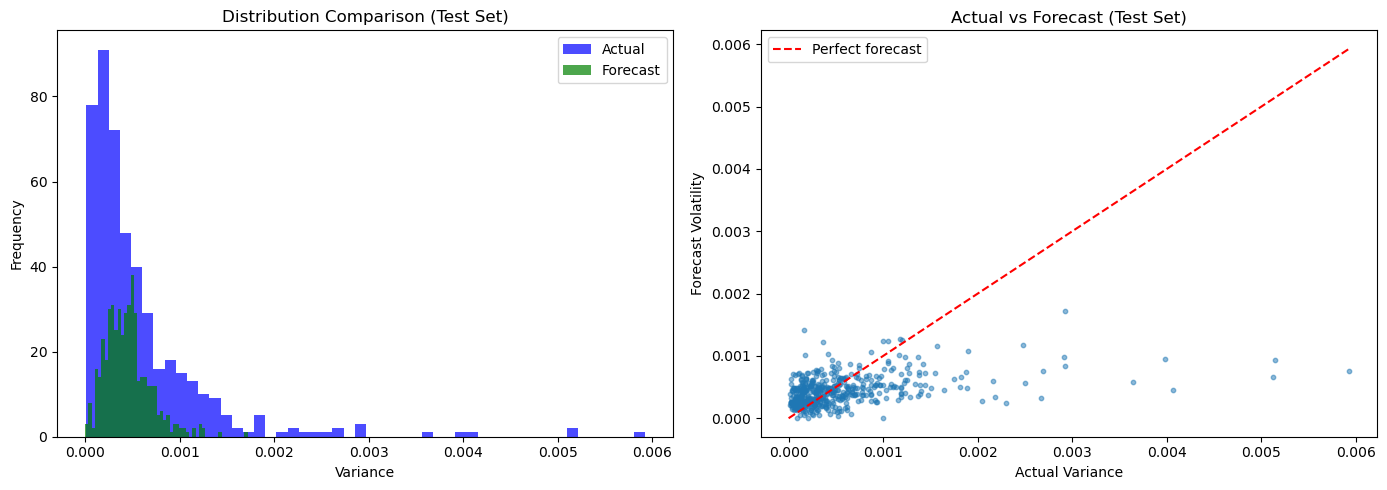


Forecast Statistics (Test Set):
  Mean forecast: 0.000448
  Mean actual:   0.000571
  Forecast std:  0.000239
  Actual std:    0.000689
  Forecasts > Actuals: 53.1%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(test_actuals, bins=50, alpha=0.7, label='Actual', color='blue')
axes[0].hist(test_preds, bins=50, alpha=0.7, label='Forecast', color='green')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution Comparison (Test Set)')
axes[0].legend()

# Actual vs Forecast scatter
axes[1].scatter(test_actuals, test_preds, alpha=0.5, s=10)
axes[1].plot([0, test_actuals.max()], [0, test_actuals.max()], 'r--', label='Perfect forecast')
axes[1].set_xlabel('Actual Variance')
axes[1].set_ylabel('Forecast Volatility')
axes[1].set_title('Actual vs Forecast (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {test_preds.mean():.6f}")
print(f"  Mean actual:   {test_actuals.mean():.6f}")
print(f"  Forecast std:  {test_preds.std():.6f}")
print(f"  Actual std:    {test_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(test_preds > test_actuals).mean()*100:.1f}%")